In [1]:
# install.packages("httr")
# install.packages("jsonlite")

library(httr)
library(jsonlite)

url <- "https://hlaazlqgqymhbaimgtdy.supabase.co"
key <- "sb_publishable_Cd6OPLfuWq6UoaKiyiZfYA_p0fYAaL7"

response <- GET(
  url = paste0(url, "/rest/v1/GEData_Raw_2021_2024"),
  add_headers(
    apikey = key,
    Authorization = paste("Bearer", key),
    `Content-Type` = "application/json"
  ),
  query = list(select = "*")
)

# Convert response to JSON
data_json <- content(response, as = "text", encoding = "UTF-8")

# Parse into R dataframe
df <- fromJSON(data_json, flatten = TRUE)

# sanity check
head(df)

,Artifact Code,Delivery,Goal,Subject,LO1,LO1.1,LO1.2,LO2,LO3,LO3.1,⋯,LO1.2.PP,LO2.PP,LO3.PP,LO3.1.PP,LO3.2.PP,LO4.PP,LO5.PP,CT:LO4+LO5.PP,Total Points Possible,Year
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ENENGL2003001.10.pdf,RSVL Campus,A&H,ENGL,3.0,NA,NA,2,3.0,NA,⋯,NA,4,4,NA,NA,NA,NA,NA,12,2021
2,HIST1503_P03_2,Concurrent,A&H,HIST,4.0,NA,NA,3,3.0,NA,⋯,NA,4,4,NA,NA,NA,NA,NA,12,2024
3,POLS2003_02_03.docx,Campus,Civic Engagement,POLS,4.0,NA,NA,2,0.0,NA,⋯,NA,8,4,NA,NA,NA,NA,NA,32,2022
4,AGBU2063_001_7,Campus,Critical Thinking,AGBU,2.0,NA,NA,4,6.0,NA,⋯,NA,8,8,NA,NA,8,8,16,36,2024
5,AGBU2063_001_8,Campus,Critical Thinking,AGBU,3.0,NA,NA,2,3.0,NA,⋯,NA,8,8,NA,NA,8,8,16,36,2024
6,AGBU2073.M01_5,Mixed Techn.,Written Communication,AGBU,2.5,3,2,2,1.5,2,⋯,4,4,8,4,4,NA,NA,NA,12,2023


In [2]:
colnames(df)

[1] "Artifact Code"            "Delivery"                
 [3] "Goal"                     "Subject"                 
 [5] "LO1"                      "LO1.1"                   
 [7] "LO1.2"                    "LO2"                     
 [9] "LO3"                      "LO3.1"                   
[11] "LO3.2"                    "LO4"                     
[13] "LO5"                      "CriticalThinking_LO4+LO5"
[15] "Rubric Score"             "LO1.PP"                  
[17] "LO1.1.PP"                 "LO1.2.PP"                
[19] "LO2.PP"                   "LO3.PP"                  
[21] "LO3.1.PP"                 "LO3.2.PP"                
[23] "LO4.PP"                   "LO5.PP"                  
[25] "CT:LO4+LO5.PP"            "Total Points Possible"   
[27] "Year"

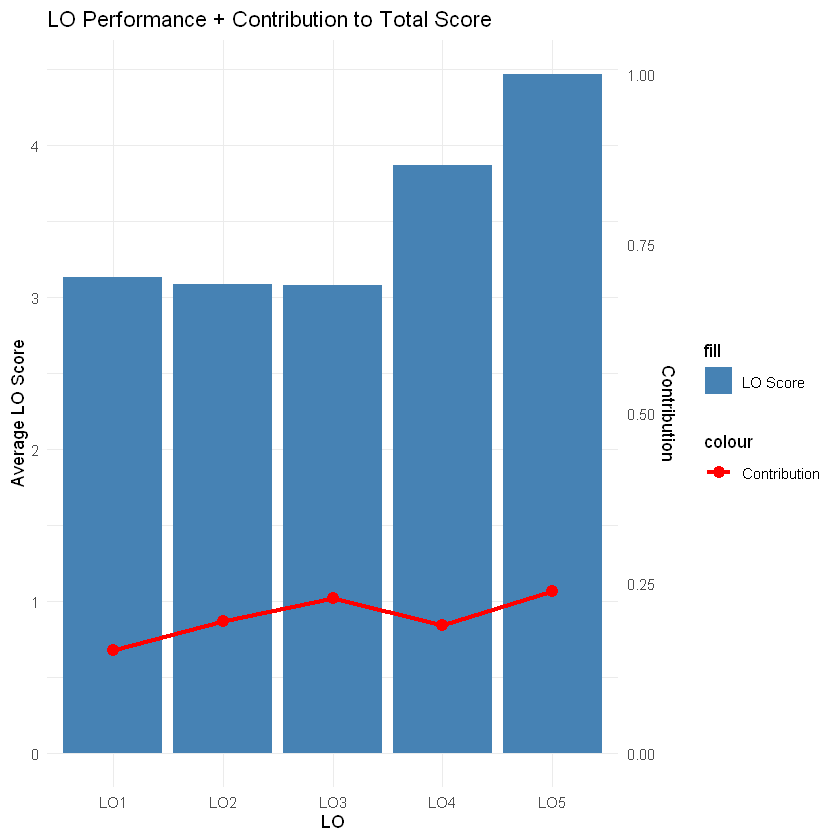

In [8]:
library(tidyverse)

df <- df %>%
  mutate(
    TPE = LO1 + LO2 + LO3 + LO4 + LO5,
    TPE_perc = TPE / 36
  )

df_long <- df %>%
  pivot_longer(
    cols = c(LO1, LO2, LO3, LO4, LO5),
    names_to = "LO",
    values_to = "score"
  )

df_summary <- df_long %>%
  group_by(LO) %>%
  summarise(
    avg_score = mean(score, na.rm = TRUE),
    contribution = mean(score / TPE, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(df_summary, aes(x = LO)) +

  # bars = actual LO performance
  geom_col(aes(y = avg_score, fill = "LO Score"), position = "dodge") +

  # line = LO contribution (this now varies!)
  geom_line(aes(y = contribution * max(avg_score), group = 1, color = "Contribution"), linewidth = 1.2) +
  geom_point(aes(y = contribution * max(avg_score), color = "Contribution"), size = 3) +

  scale_y_continuous(
    name = "Average LO Score",
    sec.axis = sec_axis(~ . / max(df_summary$avg_score), name = "Contribution")
  ) +

  scale_fill_manual(values = c("LO Score" = "steelblue")) +
  scale_color_manual(values = c("Contribution" = "red")) +

  labs(title = "LO Performance + Contribution to Total Score") +
  theme_minimal()

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'ggplot2' was built under R version 4.5.2"
Warning message:
"package 'tidyr' was built under R version 4.5.2"
Warning message:
"package 'dplyr' was built under R version 4.5.2"
Warning message:
"package 'stringr' was built under R version 4.5.2"
── Attaching core tidyverse packages ────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


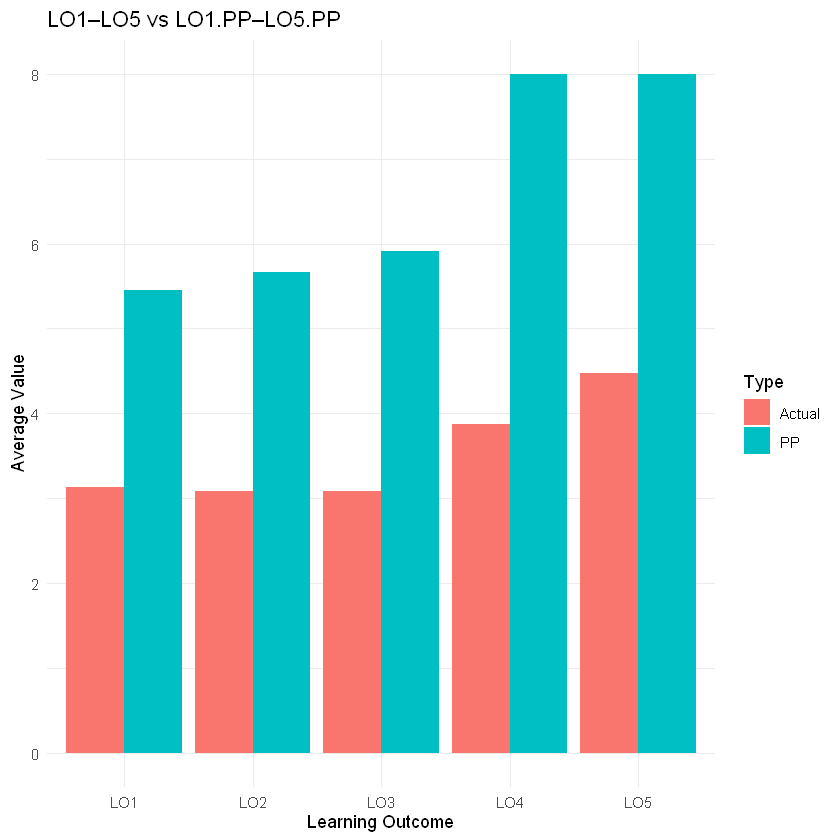

In [3]:
library(tidyverse)
df_long <- df %>%
  pivot_longer(
    cols = c(LO1, LO2, LO3, LO4, LO5,
             LO1.PP, LO2.PP, LO3.PP, LO4.PP, LO5.PP),
    names_to = "variable",
    values_to = "value"
  ) %>%
  mutate(
    LO_group = str_extract(variable, "LO[1-5]"),
    type = if_else(str_detect(variable, "PP"), "PP", "Actual")
  )

df_summary <- df_long %>%
  group_by(LO_group, type) %>%
  summarise(value = mean(value, na.rm = TRUE), .groups = "drop")

ggplot(df_summary, aes(x = LO_group, y = value, fill = type)) +
  geom_col(position = "dodge") +
  labs(
    title = "LO1–LO5 vs LO1.PP–LO5.PP",
    x = "Learning Outcome",
    y = "Average Value",
    fill = "Type"
  ) +
  theme_minimal()

Warning message:
"Removed 2 rows containing missing values or values outside the scale range (`geom_line()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range (`geom_point()`)."


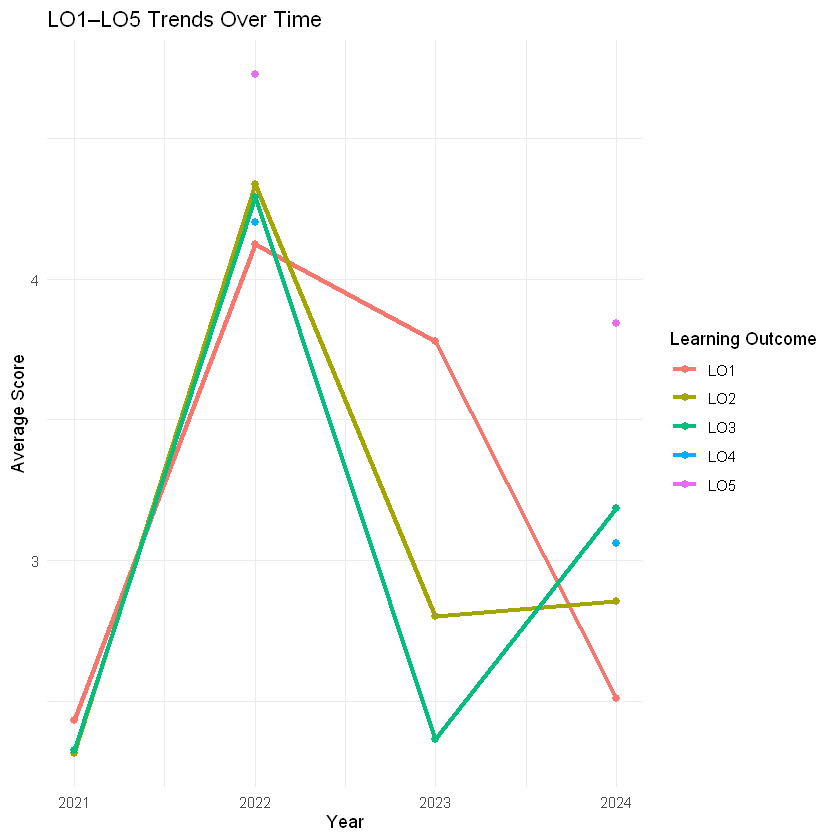

In [9]:
library(tidyverse)

df_long <- df %>%
  pivot_longer(
    cols = c(LO1, LO2, LO3, LO4, LO5),
    names_to = "LO",
    values_to = "score"
  )

df_summary <- df_long %>%
  group_by(Year, LO) %>%
  summarise(
    avg_score = mean(score, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(df_summary, aes(x = Year, y = avg_score, color = LO)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  labs(
    title = "LO1–LO5 Trends Over Time",
    x = "Year",
    y = "Average Score",
    color = "Learning Outcome"
  ) +
  theme_minimal()